# pynb: TN-Route-v2 Enterprise Diagnostic Suite
### Advanced Predictive Logistics Visualizations

This notebook contains a comprehensive suite of **Matplotlib** and **Seaborn** visualizations designed to decode the behavior of the RF-Traffic-v2.1 engine.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from scipy import stats

# Set aesthetic style - Premium Dark Mode
plt.style.use('dark_background')
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (14, 9)
plt.rcParams['axes.facecolor'] = '#0f172a'
plt.rcParams['figure.facecolor'] = '#0f172a'
plt.rcParams['grid.color'] = '#1e293b'
plt.rcParams['text.color'] = '#cbd5e1'
plt.rcParams['axes.labelcolor'] = '#cbd5e1'
plt.rcParams['xtick.color'] = '#94a3b8'
plt.rcParams['ytick.color'] = '#94a3b8'
plt.rcParams['axes.edgecolor'] = '#334155'

print("Visual Intelligence Environment Ready.")

## 1. Multiplier Distribution per Hour (Temporal Volatility)
Revealing the spread of congestion across a 24-hour cycle. High whiskers indicate high volatility during peak shifts.

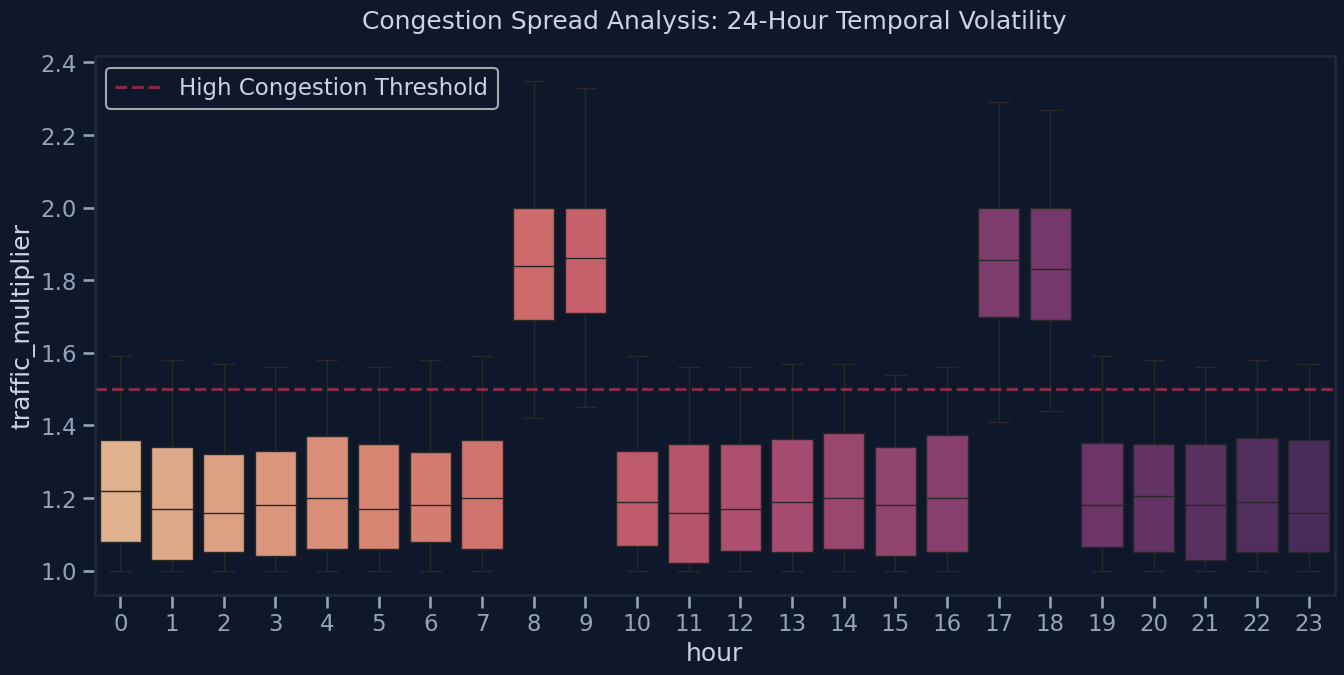

In [ ]:
data_path = '/Users/sureshkumar/prime project/tnimpact/data/traffic_data.csv'
df = pd.read_csv(data_path)

plt.figure(figsize=(16, 7))
sns.boxplot(x='hour', y='traffic_multiplier', data=df, palette='flare', hue='hour', legend=False)
plt.title('Congestion Spread Analysis: 24-Hour Temporal Volatility', fontsize=18, pad=20)
plt.axhline(y=1.5, color='#f43f5e', linestyle='--', alpha=0.5, label='High Congestion Threshold')
plt.legend()
plt.show()

## 2. Road Type Density Analysis (Violin Plots)
Comparing Highways (0) vs City Roads (1) to see the density and probability of specific delay multipliers.

/var/folders/mw/6sbdvcj9331dqxrww4bd37_80000gn/T/ipykernel_98618/3226662257.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='road_type', y='traffic_multiplier', data=df, split=True, inner="quart", palette='viridis')


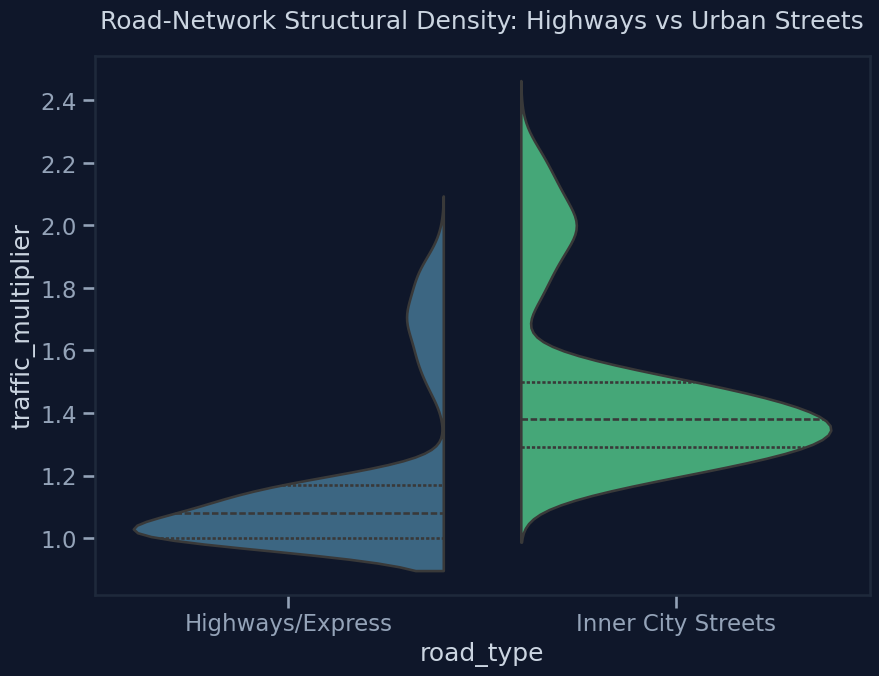

In [ ]:
plt.figure(figsize=(10, 7))
sns.violinplot(x='road_type', y='traffic_multiplier', data=df, split=True, inner="quart", palette='viridis')
plt.title('Road-Network Structural Density: Highways vs Urban Streets', fontsize=18, pad=20)
plt.xticks([0, 1], ['Highways/Express', 'Inner City Streets'])
plt.show()

## 3. Residual Error Distribution (Model Health)
Analyzing prediction errors (Actual - Predicted). A normal distribution centered at 0 indicates a well-calibrated engine.

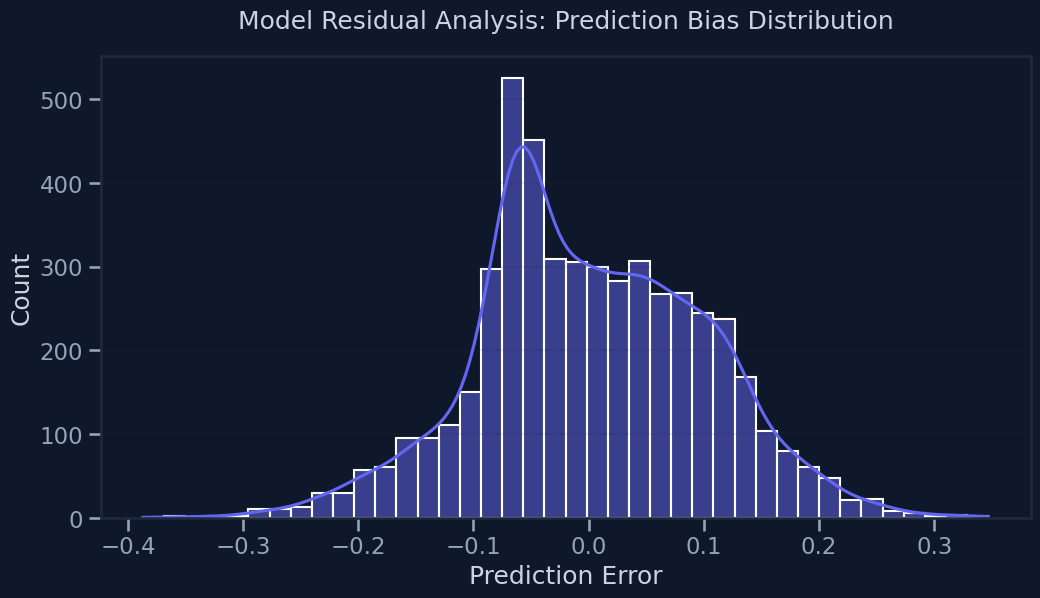

In [ ]:
model_path = '/Users/sureshkumar/prime project/tnimpact/app/models/tn_route_model_v2.pkl'
model = joblib.load(model_path)
X = df[['distance_km', 'hour', 'day_of_week', 'road_type', 'historical_speed']]
y = df['traffic_multiplier']

predictions = model.predict(X)
residuals = y - predictions

plt.figure(figsize=(12, 6))
sns.histplot(residuals, kde=True, color='#6366f1', bins=40)
plt.title('Model Residual Analysis: Prediction Bias Distribution', fontsize=18, pad=20)
plt.xlabel('Prediction Error')
plt.grid(axis='y', alpha=0.1)
plt.show()

## 4. Distance vs. Predicted Multiplier (Network Load Correlation)
Visualizing how trip length impacts the predicted congestion factor.

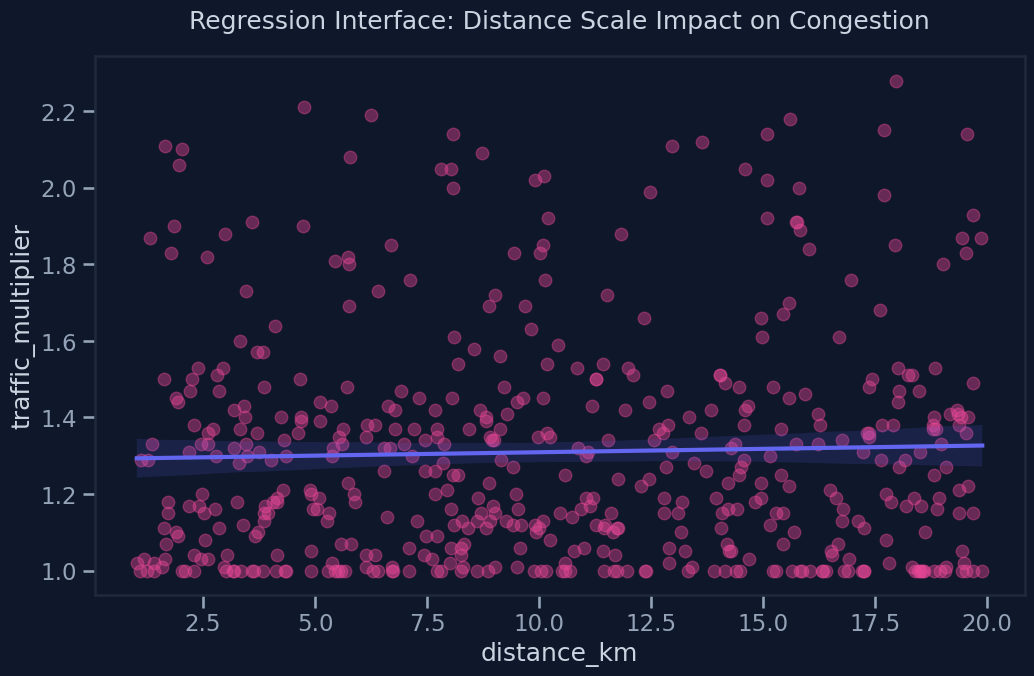

In [ ]:
plt.figure(figsize=(12, 7))
sample_df = df.sample(500)
sns.regplot(x='distance_km', y='traffic_multiplier', data=sample_df, 
            scatter_kws={'alpha':0.4, 'color': '#ec4899'}, 
            line_kws={'color':'#6366f1', 'lw':3})
plt.title('Regression Interface: Distance Scale Impact on Congestion', fontsize=18, pad=20)
plt.show()

## 5. Joint Distribution Analysis (Hour vs. Multiplier)
Hexagonal binning to visualize intense temporal clusters of congestion.

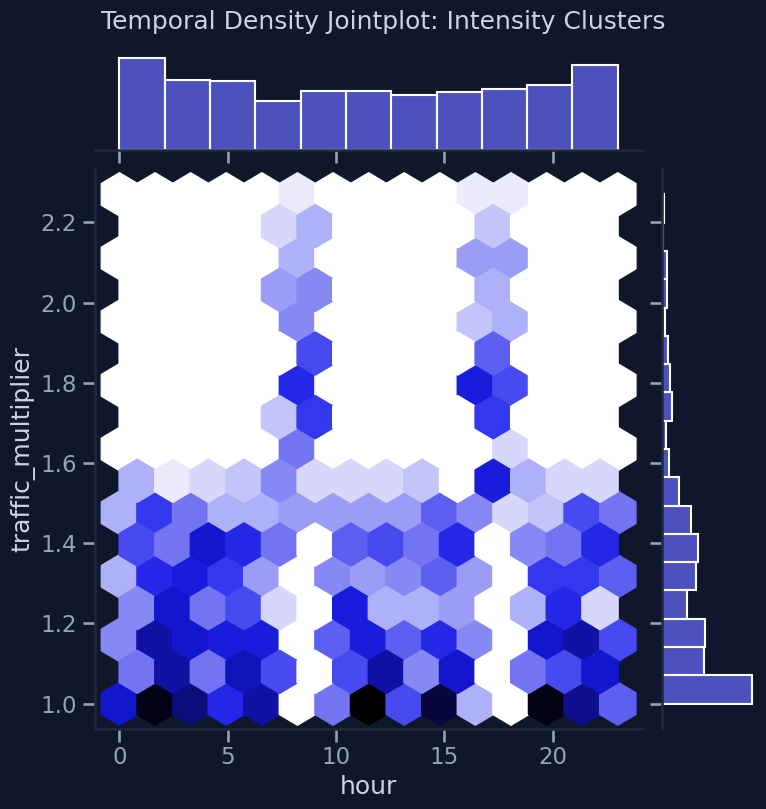

In [ ]:
sns.jointplot(x='hour', y='traffic_multiplier', data=df.sample(1000), kind="hex", color="#6366f1", height=8)
plt.suptitle('Temporal Density Jointplot: Intensity Clusters', fontsize=18, y=1.02)
plt.show()

## 6. Global Feature Pair-Relationships
Matrix mapping interaction across variables, color-coded by road type.

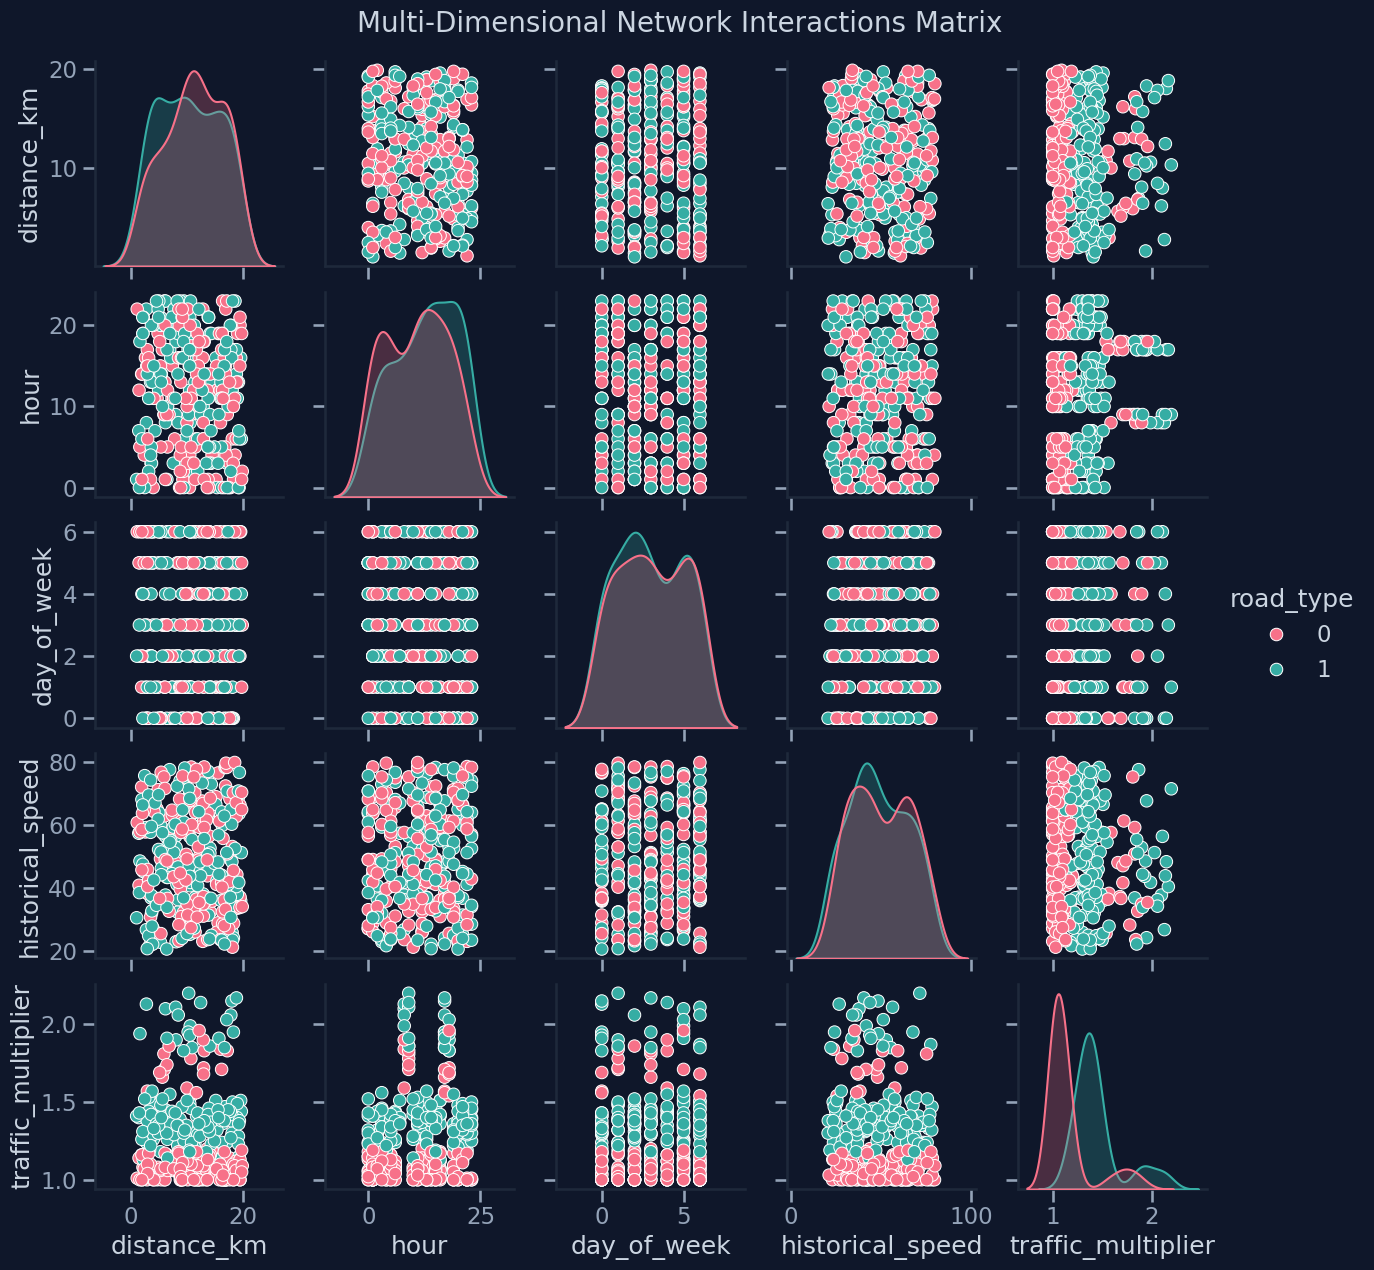

In [ ]:
sns.pairplot(df.sample(300), hue='road_type', palette='husl')
plt.suptitle('Multi-Dimensional Network Interactions Matrix', fontsize=20, y=1.02)
plt.show()

## 7. Operational Heatmap Profile
A heatmap showing the intersection of Time and Road Classification.

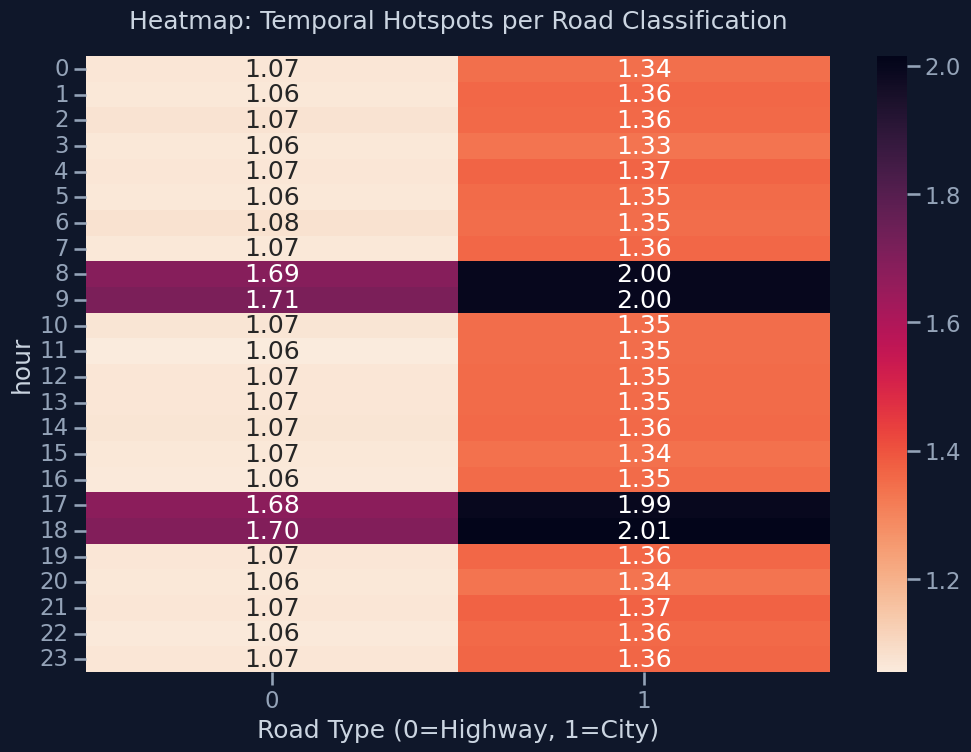

In [ ]:
pivot = df.pivot_table(index='hour', columns='road_type', values='traffic_multiplier', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='rocket_r', annot=True, fmt=".2f")
plt.title('Heatmap: Temporal Hotspots per Road Classification', fontsize=18, pad=20)
plt.xlabel('Road Type (0=Highway, 1=City)')
plt.show()